# Wavegram-Logmel-CNN Audio Feature Fusion

In [1]:
pip install datasets tqdm torch torchaudio torchcodec torchmetrics transformers ffmpeg-python ffmpeg scikit-learn seaborn librosa torch-audiomentations audiomentations wandb


  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached torchaudio-2.10.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
  Using cached torchcodec-0.10.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached torchmetrics-1.8.2-py3-none-any.whl.metadata (22 kB)
  Using cached transformers-5.0.0-py3-none-any.whl.metadata (37 kB)
  Using cached ffmpeg_python-0.2.0-py3-none-any.whl.metadata (1.7 kB)
  Using cached ffmpeg-1.4-py3-none-any.whl
  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached torch_audiomentations-0.12.0-py3-none-any.whl.metadata (15 kB)
  Using cached audiomentations-0.43.1-py3-none-any.whl.metadata (11 kB)
  Using cached wandb-0.24.0-py3-none-manylinux_2_28_x86_64.whl.metadata (12 kB)
  Using cached pyarrow-23.0.0-cp313-cp3

In [2]:
from pathlib import Path
from typing import Union

import pandas as pd
import torch
from cryptography.hazmat.primitives.keywrap import aes_key_wrap
from torch import nn, optim, Tensor
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import torchmetrics
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk, DatasetDict, load_dataset, Dataset, ClassLabel
import torchaudio
import torchaudio.transforms as T
import random
import torchcodec
import torchaudio
import datasets
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import torch_audiomentations as ta
import torch
import torch.nn as nn
from torch_audiomentations import Compose, AddColoredNoise, PitchShift, Shift
import numpy as np
from datasets import concatenate_datasets
import wandb

api = wandb.Api()

SEED = 42
SAMPLE_RATE = 16000
BATCH_SIZE = 32
NUM_WORKERS = 96
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


In [3]:
ds = load_dataset("Hibou-Foundation/big_ds_4_raw_wav_balanced")
# ("Hibou-Foundation/ds_10_raw_aug_0-5_balanced_chunked")
# ("Hibou-Foundation/big_ds_5_specto_noaug_chunked_balanced")


In [4]:
print(ds)


DatasetDict({
    train: Dataset({
        features: ['audio', 'label'],
        num_rows: 352116
    })
    val: Dataset({
        features: ['audio', 'label'],
        num_rows: 43580
    })
    test: Dataset({
        features: ['audio', 'label'],
        num_rows: 43478
    })
})


In [5]:
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
import numpy as np
from datasets import concatenate_datasets

# Define augmentation pipeline
augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.8),
    TimeStretch(min_rate=0.85, max_rate=1.15, p=0.8),
    PitchShift(min_semitones=-3, max_semitones=3, p=0.8),
])

def create_augmented_example(example):
    """Create augmented version of audio"""
    audio_array = np.array(example['audio'], dtype=np.float32)
    augmented = augment(samples=audio_array, sample_rate=16000)
    return {
        'audio': augmented.tolist(),
        'label': example['label']
    }

# Create augmented dataset (this creates NEW samples)
print("Creating augmented copies...")
augmented_train = ds['train'].map(
    create_augmented_example,
    desc="Creating augmented samples",
    num_proc=4
)

# Combine original + augmented
print("Combining original and augmented data...")
ds['train'] = concatenate_datasets([ds['train'], augmented_train])

print(f"New training size: {len(ds['train'])} samples")


Creating augmented copies...
Combining original and augmented data...
New training size: 704232 samples


In [6]:
class WavegramBranch(nn.Module):
    """1D CNN branch for learnable time-frequency representation"""
    def __init__(self, n_bins=64):
        super().__init__()
        self.n_bins = n_bins
        
        # Initial conv: filter=11, stride=5
        self.conv1 = nn.Conv1d(1, 64, kernel_size=11, stride=5, padding=5)
        self.bn1 = nn.BatchNorm1d(64)
        
        # Dilated convolutions for larger receptive field
        self.conv2 = nn.Conv1d(64, 64, kernel_size=5, dilation=2, padding=4)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.conv3 = nn.Conv1d(64, n_bins, kernel_size=5, dilation=4, padding=8)
        self.bn3 = nn.BatchNorm1d(n_bins)
        
    def forward(self, x):
        # x: (batch, 1, time_samples)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        
        # Reshape to (batch, n_bins, time_frames)
        # x is now (batch, n_bins, reduced_time)
        return x


In [7]:
class LogMelSpectrogramBranch(nn.Module):
    """Fixed time-frequency representation using log-mel spectrogram"""
    def __init__(self, sample_rate=16000, n_fft=512, hop_length=160, n_mels=64):
        super().__init__()
        self.n_mels = n_mels
        
        # MelSpectrogram transform
        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            power=2.0
        )
        
    def forward(self, x):
        # x: (batch, 1, time_samples)
        x = x.squeeze(1)  # (batch, time_samples)
        
        # Compute mel spectrogram
        mel_spec = self.mel_spectrogram(x)  # (batch, n_mels, time_frames)
        
        # Apply logarithm (with small epsilon for numerical stability)
        log_mel_spec = torch.log(mel_spec + 1e-8)
        
        return log_mel_spec


In [8]:
class CNN14Block(nn.Module):
    """2D CNN block with batch norm and ReLU"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm2d(out_channels)
        
    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))


In [9]:
class CNN14Backbone(nn.Module):
    """CNN14 backbone network for 2D feature learning"""
    def __init__(self, in_channels, num_classes):
        super().__init__()
        
        # CNN blocks with increasing channels
        self.block1 = nn.Sequential(
            CNN14Block(in_channels, 64),
            CNN14Block(64, 64),
            nn.MaxPool2d(2)
        )
        
        self.block2 = nn.Sequential(
            CNN14Block(64, 128),
            CNN14Block(128, 128),
            nn.MaxPool2d(2)
        )
        
        self.block3 = nn.Sequential(
            CNN14Block(128, 256),
            CNN14Block(256, 256),
            nn.MaxPool2d(2)
        )
        
        self.block4 = nn.Sequential(
            CNN14Block(256, 512),
            CNN14Block(512, 512),
            nn.MaxPool2d(2)
        )
        
        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Final classification layer
        self.fc = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        
        # Global pooling
        x = self.global_pool(x)  # (batch, 512, 1, 1)
        x = x.flatten(1)  # (batch, 512)
        
        # Classification
        x = self.fc(x)
        return x


In [10]:
class PANN(nn.Module):
    """Pretrained Audio Neural Network with dual-branch architecture"""
    def __init__(self, num_classes, sample_rate=16000, n_mels=64):
        super().__init__()
        
        # Wavegram branch (learnable)
        self.wavegram_branch = WavegramBranch(n_bins=n_mels)
        
        # Log-mel spectrogram branch (fixed)
        self.logmel_branch = LogMelSpectrogramBranch(
            sample_rate=sample_rate,
            n_mels=n_mels
        )
        
        # Backbone network (concatenated features: 2 channels from 2 branches)
        self.backbone = CNN14Backbone(in_channels=2, num_classes=num_classes)
        
    def forward(self, x):
        # x: (batch, 1, time_samples) - raw waveform
        
        # Extract features from both branches
        wavegram = self.wavegram_branch(x)  # (batch, n_mels, time_frames)
        logmel = self.logmel_branch(x)      # (batch, n_mels, time_frames)
        
        # Align time dimensions if needed
        min_time = min(wavegram.size(2), logmel.size(2))
        wavegram = wavegram[:, :, :min_time]
        logmel = logmel[:, :, :min_time]
        
        # Concatenate along channel dimension
        # Add channel dimension: (batch, 1, n_mels, time_frames)
        wavegram = wavegram.unsqueeze(1)
        logmel = logmel.unsqueeze(1)
        
        # Fused features: (batch, 2, n_mels, time_frames)
        fused = torch.cat([wavegram, logmel], dim=1)
        
        # Pass through backbone
        output = self.backbone(fused)
        
        return output


In [11]:
class AudioDataset(Dataset):
    """Wrapper for HuggingFace audio dataset"""
    def __init__(self, hf_dataset, duration=0.5):
        # Reset format to remove HF's __getitems__ optimization
        if hasattr(hf_dataset, 'with_format'):
            self.dataset = hf_dataset.with_format(None)
        else:
            self.dataset = hf_dataset

        self.target_length = int(SAMPLE_RATE * duration)

    @staticmethod
    def _extract_audio_data(item):
        """Extract audio array and sampling rate from item"""
        audio_field = item.get('audio')

        if audio_field is None:
            raise ValueError("No 'audio' field found in dataset item")

        # Case 1: audio is a dictionary (standard HF format)
        if isinstance(audio_field, dict):
            audio_array = audio_field.get('array')
            sr = audio_field.get('sampling_rate', SAMPLE_RATE)

            if audio_array is None:
                # Try to find audio data in other possible keys
                for key in ['array', 'data', 'samples', 'waveform']:
                    if key in audio_field:
                        audio_array = audio_field[key]
                        break

            if audio_array is None:
                raise ValueError(f"Could not find audio array in dict: {list(audio_field.keys())}")

        elif isinstance(audio_field, datasets.features._torchcodec.AudioDecoder):
            audio_array = audio_field["array"]
            sr = audio_field["sampling_rate"]

        # Case 2: audio is a list/numpy array
        elif isinstance(audio_field, (list, np.ndarray)):
            audio_array = audio_field
            sr = SAMPLE_RATE  # Assume default sampling rate

        # Case 3: audio is a string/path (unlikely but possible)
        elif isinstance(audio_field, str):
            raise ValueError(f"Audio field is a string (path), not supported: {audio_field}")

        else:
            raise TypeError(f"Unknown audio field type: {type(audio_field)}")

        return audio_array, sr

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        # Get audio (assuming it's in 'audio' field)
        audio_array, sr = self._extract_audio_data(item)

        # Convert to tensor
        if isinstance(audio_array, np.ndarray):
            audio = torch.from_numpy(audio_array).float()
        elif isinstance(audio_array, list):
            audio = torch.tensor(audio_array, dtype=torch.float32)
        elif isinstance(audio_array, torch.Tensor):
            audio = audio_array.float()
        else:
            raise TypeError(f"Unsupported audio array type: {type(audio_array)}")

        # Ensure 1D
        if audio.dim() == 1:
            audio = audio.squeeze()

        # Pad or truncate to target length
        if len(audio) < self.target_length:
            audio = F.pad(audio, (0, self.target_length - len(audio)))
        else:
            audio = audio[:self.target_length]

        # Add channel dimension: (1, time_samples)
        audio = audio.unsqueeze(0)

        # Get label (adjust field name as needed)
        label = item['label']
        if isinstance(label, (list, np.ndarray)):
            label = torch.FloatTensor(label)
        elif isinstance(label, int):
            # Convert single-label to one-hot or keep as int depending on your task
            label = torch.tensor(label, dtype=torch.long)
        else:
            label = torch.FloatTensor([label]) if not isinstance(label, torch.Tensor) else label.float()

        return audio, label

    def __getitems__(self, indices):
        # Override to prevent HuggingFace's batch optimization
        #return [self.__getitem__(i) for i in indices]

        items = [self.dataset[idx] for idx in indices]
        audios = [self._extract_audio_data(it) for it in items]

        testing = audios[0]
        if isinstance(testing[0], np.ndarray):
            audios = [torch.from_numpy(audio[0]).float() for audio in audios]
            if testing[0].ndim == 1:
                audios = [audio.squeeze() for audio in audios]

        elif isinstance(testing[0], list):
            audios = [torch.tensor(audio[0], dtype=torch.float32) for audio in audios]

        elif isinstance(testing[0], torch.Tensor):
            audios = [audio[0].float() for audio in audios]
            if testing[0].dim() == 1:
                audios = [audio.squeeze() for audio in audios]

        else:
            raise TypeError(f"Unsupported audio array type: {type(audio_array)}")


        audios = [F.pad(audio, (0, self.target_length - len(audio))) if len(audio) < self.target_length else audio[:self.target_length] for audio in audios]

        audios = [audio.unsqueeze(0) for audio in audios]

        l = items[0]['label']
        if isinstance(l, (list, np.ndarray)):
            labels = [torch.FloatTensor(it["label"]) for it in items]
        elif isinstance(l, int):
            # Convert single-label to one-hot or keep as int depending on your task
            labels = [torch.tensor(it["label"], dtype=torch.long) for it in items]
        else:
            labels = [torch.FloatTensor([it["label"]]) if not isinstance(label, torch.Tensor) else label.float() for it in items]

        return list(zip(audios, labels))


In [127]:
def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=10,
    device='cuda',
    checkpoint_path='best_model.pt'
):
    """Training loop for PANN with progress bars and best-model checkpointing"""

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Determine loss function based on label type
    sample_batch = next(iter(train_loader))
    sample_labels = sample_batch[1]

    if sample_labels.dtype == torch.long:
        criterion = nn.CrossEntropyLoss()
        is_multilabel = False
        print("Using CrossEntropyLoss for single-label classification")
    else:
        criterion = nn.BCEWithLogitsLoss()
        is_multilabel = True
        print("Using BCEWithLogitsLoss for multi-label classification")

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # ======================
        # Training phase
        # ======================
        model.train()
        train_loss = 0.0

        train_pbar = tqdm(
            train_loader,
            desc=f'Epoch {epoch+1}/{num_epochs} [Train]'
        )

        for audio, labels in train_pbar:
            audio = audio.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(audio)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_train_loss = train_loss / len(train_loader)

        # ======================
        # Validation phase
        # ======================
        model.eval()
        val_loss = 0.0

        val_pbar = tqdm(
            val_loader,
            desc=f'Epoch {epoch+1}/{num_epochs} [Val]'
        )

        with torch.no_grad():
            for audio, labels in val_pbar:
                audio = audio.to(device)
                labels = labels.to(device)

                outputs = model(audio)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_val_loss = val_loss / len(val_loader)

        # ======================
        # Checkpointing
        # ======================
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            torch.save(
                {
                    'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': best_val_loss,
                },
                checkpoint_path
            )

            print(
                f'✅ Saved new best model '
                f'(val loss: {best_val_loss:.4f})'
            )

        # ======================
        # Epoch summary
        # ======================
        print(
            f'Epoch {epoch+1}/{num_epochs} - '
            f'Train Loss: {avg_train_loss:.4f}, '
            f'Val Loss: {avg_val_loss:.4f}\n'
        )


In [12]:
model = PANN(num_classes=2, sample_rate=16000, n_mels=64)

print(f"Model initialized with {sum(p.numel() for p in model.parameters())} parameters")


Model initialized with 4731906 parameters


In [129]:
# Example: Load your HuggingFace dataset
# from datasets import load_dataset
# dataset = load_dataset('your_dataset_name')
train_dataset = AudioDataset(ds['train'])
val_dataset = AudioDataset(ds['val'])
test_dataset = AudioDataset(ds['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


In [125]:
def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=10,
    device='cuda',
    checkpoint_path='best_model.pt',
    use_augmentation=True
):
    """Training loop for PANN with progress bars and best-model checkpointing"""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-6) # 1e-4

    # Define augmentation pipeline
    if use_augmentation:
        augment = Compose(
            transforms=[
                AddColoredNoise(p=0.5, min_snr_in_db=10, max_snr_in_db=30),
                PitchShift(
                    min_transpose_semitones=-2,
                    max_transpose_semitones=2,
                    p=0.5,
                    sample_rate=16000
                ),
                Shift(min_shift=-0.5, max_shift=0.5, p=0.5),
            ]
        ).to(device)
    
    # Determine loss function based on label type
    sample_batch = next(iter(train_loader))
    sample_labels = sample_batch[1]
    if sample_labels.dtype == torch.long:
        criterion = nn.CrossEntropyLoss()
        is_multilabel = False
        print("Using CrossEntropyLoss for single-label classification")
    else:
        criterion = nn.BCEWithLogitsLoss()
        is_multilabel = True
        print("Using BCEWithLogitsLoss for multi-label classification")
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_pbar = tqdm(
            train_loader,
            desc=f'Epoch {epoch+1}/{num_epochs} [Train]'
        )
        
        for audio, labels in train_pbar:
            audio = audio.to(device)
            labels = labels.to(device)
            
            # Apply augmentation only during training
            if use_augmentation:
                audio = augment(audio, sample_rate=16000)
            
            optimizer.zero_grad()
            outputs = model(audio)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation phase (no augmentation)
        model.eval()
        val_loss = 0.0
        val_pbar = tqdm(
            val_loader,
            desc=f'Epoch {epoch+1}/{num_epochs} [Val]'
        )
        
        with torch.no_grad():
            for audio, labels in val_pbar:
                audio = audio.to(device)
                labels = labels.to(device)
                outputs = model(audio)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_val_loss = val_loss / len(val_loader)

        # Checkpointing
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(
                {
                    'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': best_val_loss,
                },
                checkpoint_path
            )
            print(f'✅ Saved new best model (val loss: {best_val_loss:.4f})')

        print(
            f'Epoch {epoch+1}/{num_epochs} - '
            f'Train Loss: {avg_train_loss:.4f}, '
            f'Val Loss: {avg_val_loss:.4f}\n'
        )


In [130]:
# Train model
train_model(model, train_loader, val_loader, num_epochs=10, device='cuda', checkpoint_path='./pann_best_model.aug.pt')


Using CrossEntropyLoss for single-label classification


Epoch 1/10 [Val]: 100%|██████████| 1362/1362 [02:03<00:00, 11.03it/s, loss=0.0024]


✅ Saved new best model (val loss: 0.0514)
Epoch 1/10 - Train Loss: 0.0671, Val Loss: 0.0514



Epoch 2/10 [Val]: 100%|██████████| 1362/1362 [01:59<00:00, 11.36it/s, loss=0.0004]


✅ Saved new best model (val loss: 0.0456)
Epoch 2/10 - Train Loss: 0.0361, Val Loss: 0.0456



...

Epoch 3/10 - Train Loss: 0.0282, Val Loss: 0.0591



Epoch 4/10 [Val]: 100%|██████████| 1362/1362 [02:06<00:00, 10.80it/s, loss=0.0046]


Epoch 4/10 - Train Loss: 0.0236, Val Loss: 0.0554



Epoch 5/10 [Train]:   5%|▍         | 1018/22008 [01:54<39:28,  8.86it/s, loss=0.0039] 


KeyboardInterrupt: 

In [132]:
test_loader = DataLoader(test_dataset, batch_size=32)


In [13]:
checkpoint = torch.load('./pann_best_model.pt', map_location=torch.device("cuda"), weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


PANN(
  (wavegram_branch): WavegramBranch(
    (conv1): Conv1d(1, 64, kernel_size=(11,), stride=(5,), padding=(5,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(4,))
    (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (logmel_branch): LogMelSpectrogramBranch(
    (mel_spectrogram): MelSpectrogram(
      (spectrogram): Spectrogram()
      (mel_scale): MelScale()
    )
  )
  (backbone): CNN14Backbone(
    (block1): Sequential(
      (0): CNN14Block(
        (conv): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): C

In [14]:
ds_all_tests = load_dataset("Hibou-Foundation/drone_all_test_datasets")
ds_test_1 = ds_all_tests["drone_test"]
ds_test_2 = ds_all_tests["drone_test_2"]
ds_parabole_1 = ds_all_tests["mic_parabole"]
ds_parabole_2 = ds_all_tests["parabole2"]
test_dataset = ds['test']


In [22]:
model.to("cuda")


PANN(
  (wavegram_branch): WavegramBranch(
    (conv1): Conv1d(1, 64, kernel_size=(11,), stride=(5,), padding=(5,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(4,))
    (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (logmel_branch): LogMelSpectrogramBranch(
    (mel_spectrogram): MelSpectrogram(
      (spectrogram): Spectrogram()
      (mel_scale): MelScale()
    )
  )
  (backbone): CNN14Backbone(
    (block1): Sequential(
      (0): CNN14Block(
        (conv): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): C

In [23]:
model.eval()


PANN(
  (wavegram_branch): WavegramBranch(
    (conv1): Conv1d(1, 64, kernel_size=(11,), stride=(5,), padding=(5,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(4,))
    (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (logmel_branch): LogMelSpectrogramBranch(
    (mel_spectrogram): MelSpectrogram(
      (spectrogram): Spectrogram()
      (mel_scale): MelScale()
    )
  )
  (backbone): CNN14Backbone(
    (block1): Sequential(
      (0): CNN14Block(
        (conv): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): C

In [28]:
run = wandb.init(entity="hibou", project="acoustic", name="Wav-Raw-CNN")


In [39]:
def run_tests(sets, upload=False):
    names = ['no_drone', 'drone']

    for (s, n) in sets:
        ad = AudioDataset(s)
        dl = DataLoader(ad, batch_size=32)

        y_true, y_pred = [], []

        with torch.no_grad():
            for x, y in tqdm(dl, desc=n):
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                preds = out.argmax(dim=1)
                y_true.extend(y.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        print("\n\n")
        print("="*10, n, "="*10)
        print("\n\n")
        print(classification_report(y_true, y_pred, target_names=ds["train"].features["label"].names, digits=3))

        if upload:
            upload_name = n + "/confusion_matrix"
            run.log({
                upload_name: wandb.plot.confusion_matrix(
                    y_true=y_true,
                    preds=y_pred,
                    class_names=names,
                    title=f"Confusion Matrix - {n}"
                )
            })

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10,8))
        sns.heatmap(cm, annot=True, fmt="d", xticklabels=ds["train"].features["label"].names, yticklabels=ds["train"].features["label"].names)
        plt.xlabel("Prediction")
        plt.ylabel("Truth")
        plt.title(f"Confusion Matrix - {n}")
        plt.show()


In [40]:
l = [(ds_test_1, "test_online_1"), (ds_test_2, "test_online_2"), (ds_parabole_1, "test_parabole"), (ds_parabole_2, "test_parabole2"), (test_dataset, "test")]


test_online_1: 100%|██████████| 28/28 [00:00<00:00, 35.39it/s]





========== test_online_1 ==========



              precision    recall  f1-score   support

       other      0.620     1.000     0.765       509
       drone      1.000     0.188     0.316       384

    accuracy                          0.651       893
   macro avg      0.810     0.594     0.541       893
weighted avg      0.783     0.651     0.572       893



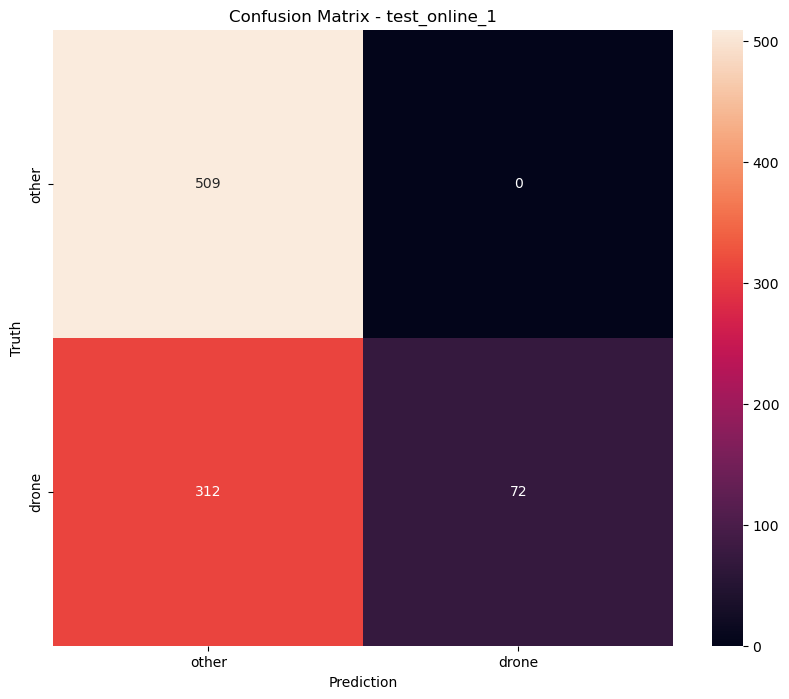

test_online_2: 100%|██████████| 88/88 [00:02<00:00, 35.57it/s]





========== test_online_2 ==========



              precision    recall  f1-score   support

       other      0.003     1.000     0.006         1
       drone      1.000     0.887     0.940      2804

    accuracy                          0.887      2805
   macro avg      0.502     0.943     0.473      2805
weighted avg      1.000     0.887     0.940      2805



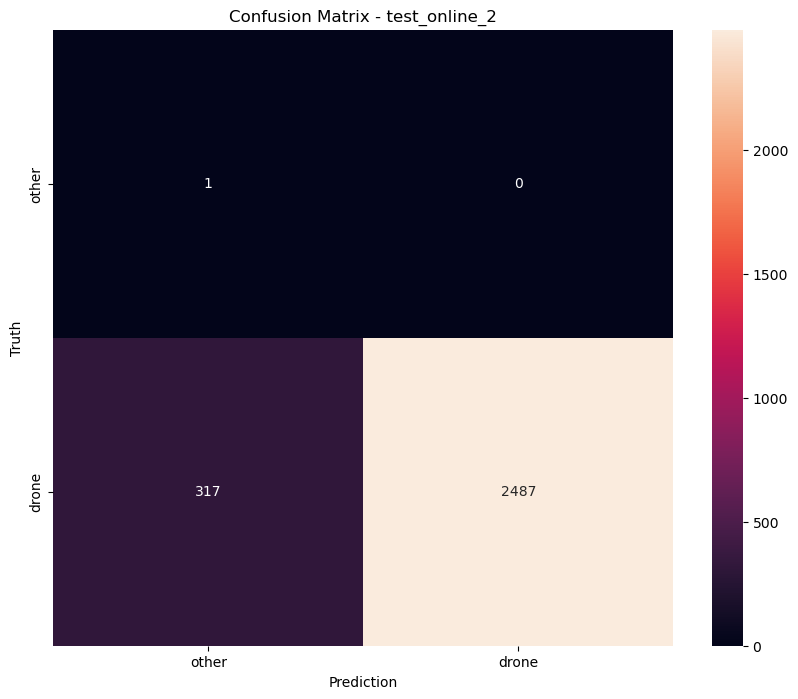

test_parabole: 100%|██████████| 4/4 [00:00<00:00, 33.57it/s]
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()




========== test_parabole ==========



              precision    recall  f1-score   support

       other      0.366     1.000     0.536        45
       drone      0.000     0.000     0.000        78

    accuracy                          0.366       123
   macro avg      0.183     0.500     0.268       123
weighted avg      0.134     0.366     0.196       123



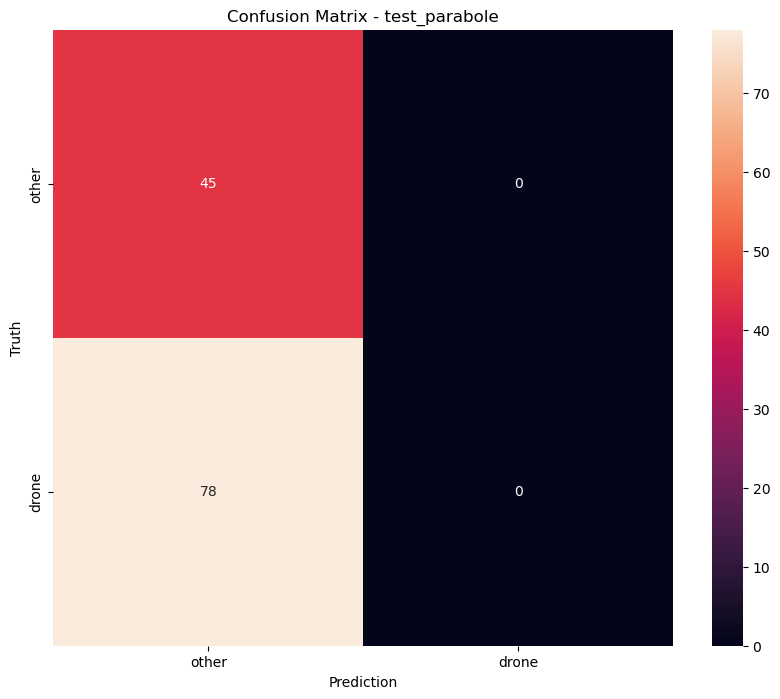

test_parabole2: 100%|██████████| 3/3 [00:00<00:00, 37.93it/s]
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(




========== test_parabole2 ==========



              precision    recall  f1-score   support

       other      0.306     1.000     0.468        26
       drone      0.000     0.000     0.000        59

    accuracy                          0.306        85
   macro avg      0.153     0.500     0.234        85
weighted avg      0.094     0.306     0.143        85



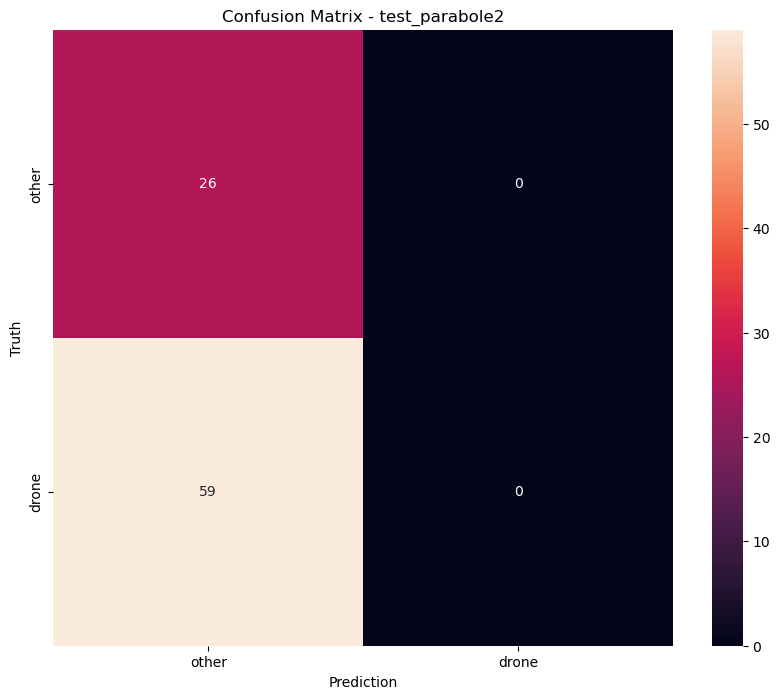

test: 100%|██████████| 1359/1359 [01:59<00:00, 11.41it/s]





========== test ==========



              precision    recall  f1-score   support

       other      0.998     0.998     0.998     21739
       drone      0.998     0.998     0.998     21739

    accuracy                          0.998     43478
   macro avg      0.998     0.998     0.998     43478
weighted avg      0.998     0.998     0.998     43478



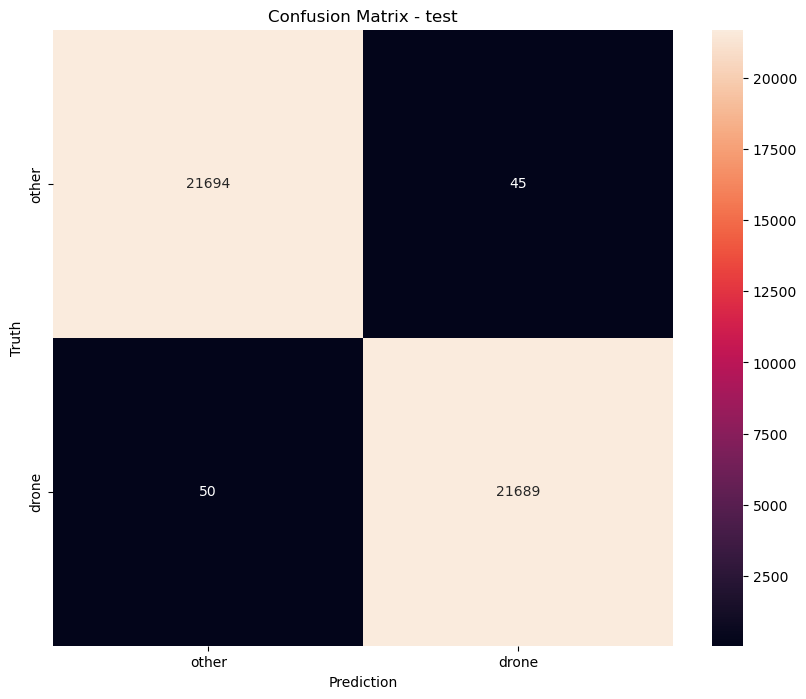

wandb: 
wandb: 🚀 View run Wav-Raw-CNN at: https://wandb.ai/hibou/acoustic/runs/m8j6azai
wandb: Find logs at: wandb/run-20260128_091128-m8j6azai/logs


In [41]:
run_tests(l, upload=True)
